In [1]:
import pandas as pd
import numpy as np

In [6]:
df = pd.read_csv(
    "../data/raw/dataset.csv",
    encoding="latin1"
)

C:\Users\RUSHIKESH\AppData\Local\Temp\ipykernel_14484\4013725079.py:1: DtypeWarning: Columns (0: Rate) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [4]:
df.head()

,Product_name,Price,Rate,Review,Summary
0,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",5,Simply awesome,it's really worth every single penny. it works...
1,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",4,Worth the money . Desert Cooler live up to the...,I bought Crompton Ozone 75 Desert Air Cooler i...
2,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",5,Worth every penny,GREAT packaging by seller. As this was the mos...
3,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",5,Fabulous!,Delivery was delayed by two days except this e...
4,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",4,Nice product,A Good cooler by Crompton. The height of the c...


In [7]:
df.shape


(363261, 5)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 363261 entries, 0 to 363260
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Product_name  363246 non-null  str   
 1   Price         363245 non-null  str   
 2   Rate          363245 non-null  object
 3   Review        363239 non-null  str   
 4   Summary       361239 non-null  str   
dtypes: object(1), str(4)
memory usage: 13.9+ MB


In [9]:
df["Rate"].value_counts(dropna=False)

Rate
5                                                              146763
5.0                                                             57069
4                                                               53843
1                                                               28375
3                                                               23763
4.0                                                             20409
1.0                                                             11702
2                                                                9379
3.0                                                              8335
2.0                                                              3601
NaN                                                                16
product_name                                                        3
Pigeon Favourite Electric Kettle????(1.5 L, Silver, Black)          1
Bajaj DX 2 L/W Dry Iron                                             1
Nova Plus Amaze

In [10]:
df["Rate"] = pd.to_numeric(
    df["Rate"],
    errors="coerce"
)

In [11]:
df["Rate"].dtype

dtype('float64')

In [12]:
df["Rate"].value_counts(dropna=False).sort_index()

Rate
1.0     40077
2.0     12980
3.0     32098
4.0     74252
5.0    203832
NaN        22
Name: count, dtype: int64

In [13]:
df.isnull().sum()


Product_name      15
Price             16
Rate              22
Review            22
Summary         2022
dtype: int64

In [14]:
(df.isnull().sum() / len(df)) * 100

Product_name    0.004129
Price           0.004405
Rate            0.006056
Review          0.006056
Summary         0.556625
dtype: float64

In [15]:
df = df.dropna(
    subset=["Product_name", "Rate", "Review", "Summary"]
)

In [16]:
df = df.reset_index(drop=True)

In [17]:
df.duplicated().sum()


np.int64(53257)

In [19]:
df.duplicated(
    subset=["Product_name", "Review", "Summary", "Rate"]
).sum()

np.int64(54913)

In [20]:
print("Full row duplicates:", df.duplicated().sum())

print(
    "Review-level duplicates:",
    df.duplicated(
        subset=["Product_name", "Review", "Summary", "Rate"]
    ).sum()
)

Full row duplicates: 53257
Review-level duplicates: 54913


In [21]:
print("Full row duplicates:", df.duplicated().sum())

print(
    "Review-level duplicates:",
    df.duplicated(
        subset=["Product_name", "Review", "Summary", "Rate"]
    ).sum()
)

Full row duplicates: 53257
Review-level duplicates: 54913


In [22]:
print("Before removing duplicates:", df.shape)

Before removing duplicates: (361229, 5)


In [23]:
df = df.drop_duplicates(
    subset=["Product_name", "Rate", "Review", "Summary"]
)

In [24]:
df = df.reset_index(drop=True)

In [25]:
print("After removing duplicates:", df.shape)

print(
    "Remaining duplicates:",
    df.duplicated(
        subset=["Product_name", "Rate", "Review", "Summary"]
    ).sum()
)

After removing duplicates: (306316, 5)
Remaining duplicates: 0


In [26]:
df["Product_name"].head(10).tolist()

['Crompton 75 L Desert Air Cooler?\x98?\x98(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler?\x98?\x98(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler?\x98?\x98(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler?\x98?\x98(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler?\x98?\x98(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler?\x98?\x98(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler?\x98?\x98(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler?\x98?\x98(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler?\x98?\x98(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler?\x98?\x98(White, Teal, ACGC-DAC751)']

In [27]:
df["Review"].head(10).tolist()

['Simply awesome',
 'Worth the money . Desert Cooler live up to the Name .',
 'Worth every penny',
 'Fabulous!',
 'Nice product',
 'Super!',
 'Terrific purchase',
 'Classy product',
 'Perfect product!',
 'Its not a cooler its Ac cooler']

In [28]:
df["Product_name"].head(10).tolist()

['Crompton 75 L Desert Air Cooler?\x98?\x98(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler?\x98?\x98(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler?\x98?\x98(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler?\x98?\x98(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler?\x98?\x98(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler?\x98?\x98(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler?\x98?\x98(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler?\x98?\x98(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler?\x98?\x98(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler?\x98?\x98(White, Teal, ACGC-DAC751)']

In [29]:
import re

def clean_product_name(text):
    text = str(text)
    
    # Remove control/non-printable characters
    text = re.sub(r'[\x00-\x1F\x7F-\x9F]', '', text)
    
    # Remove repeated ? symbols caused by encoding corruption
    text = re.sub(r'\?{2,}', '', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [30]:
df["Product_name"] = df["Product_name"].apply(clean_product_name)

In [31]:
df["Product_name"].head(10).tolist()

['Crompton 75 L Desert Air Cooler(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler(White, Teal, ACGC-DAC751)',
 'Crompton 75 L Desert Air Cooler(White, Teal, ACGC-DAC751)']

In [32]:
df["full_review"] = (
    df["Review"].str.strip()
    + " "
    + df["Summary"].str.strip()
)

In [33]:
df[["Review", "Summary", "full_review"]].head()

,Review,Summary,full_review
0,Simply awesome,it's really worth every single penny. it works...,Simply awesome it's really worth every single ...
1,Worth the money . Desert Cooler live up to the...,I bought Crompton Ozone 75 Desert Air Cooler i...,Worth the money . Desert Cooler live up to the...
2,Worth every penny,GREAT packaging by seller. As this was the mos...,Worth every penny GREAT packaging by seller. A...
3,Fabulous!,Delivery was delayed by two days except this e...,Fabulous! Delivery was delayed by two days exc...
4,Nice product,A Good cooler by Crompton. The height of the c...,Nice product A Good cooler by Crompton. The he...


In [34]:
def create_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

In [35]:
df["sentiment"] = df["Rate"].apply(create_sentiment)

In [37]:
df[["Rate", "Review", "sentiment"]].head(100)


,Rate,Review,sentiment
0,5.0,Simply awesome,Positive
1,4.0,Worth the money . Desert Cooler live up to the...,Positive
2,5.0,Worth every penny,Positive
3,5.0,Fabulous!,Positive
4,4.0,Nice product,Positive
...,...,...,...
95,5.0,Brilliant,Positive
96,5.0,Super!Excelleant product,Positive
97,5.0,Fabulous!,Positive
98,5.0,Brilliant,Positive


In [38]:
df["sentiment"].value_counts()

sentiment
Positive    228848
Negative     49618
Neutral      27850
Name: count, dtype: int64

In [39]:
import matplotlib.pyplot as plt

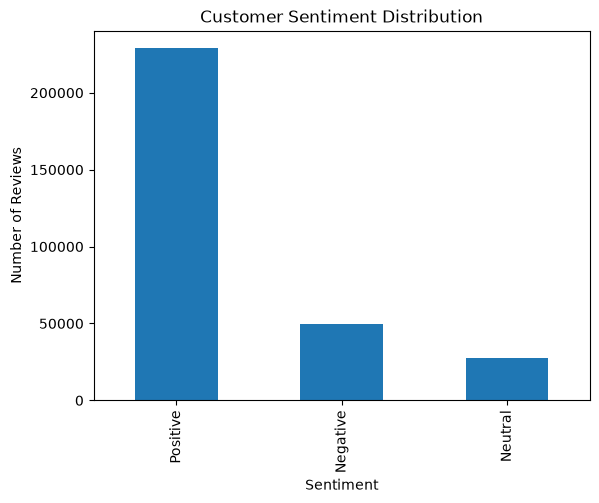

In [40]:
sentiment_counts = df["sentiment"].value_counts()

sentiment_counts.plot(kind="bar")

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [41]:
average_rating = df["Rate"].mean()

print("Average Customer Rating:", round(average_rating, 2))

Average Customer Rating: 4.01


In [42]:
rating_counts = df["Rate"].value_counts().sort_index()
rating_counts

Rate
1.0     37443
2.0     12175
3.0     27850
4.0     60030
5.0    168818
Name: count, dtype: int64

In [43]:
print("Average Customer Rating:", round(df["Rate"].mean(), 2))

Average Customer Rating: 4.01


In [44]:
df["Product_name"].nunique()

1152

In [45]:
top_products = df["Product_name"].value_counts().head(10)

top_products

Product_name
cello Pack of 18 Opalware Cello Dazzle Lush Fiesta Opalware Dinner Set, 18 Pieces Dinner Set(White, Microwave Safe)    6947
Bumtum Baby Pull-Up Diaper Pants Combo Pack - L(186 Pieces)                                                            6900
Google Home Mini with Google Assistant Smart Speaker(Charcoal)                                                         6836
Mi 5A 80 cm (32 inch) HD Ready LED Smart Android TV with Dolby Audio (2022 Model)                                      6522
MILTON Thermosteel Flip Lid 500 ml Flask(Pack of 1, Silver, Steel)                                                     5935
Lakm Eyeconic Kajal Twin Pack(Deep Black, 0.7 g)                                                                       5071
Crompton 75 L Desert Air Cooler(White, Teal, ACGC-DAC751)                                                              4481
Crompton 88 L Desert Air Cooler with Honeycomb Cooling Pad(White, Teal, ACGC-DAC881)                                   

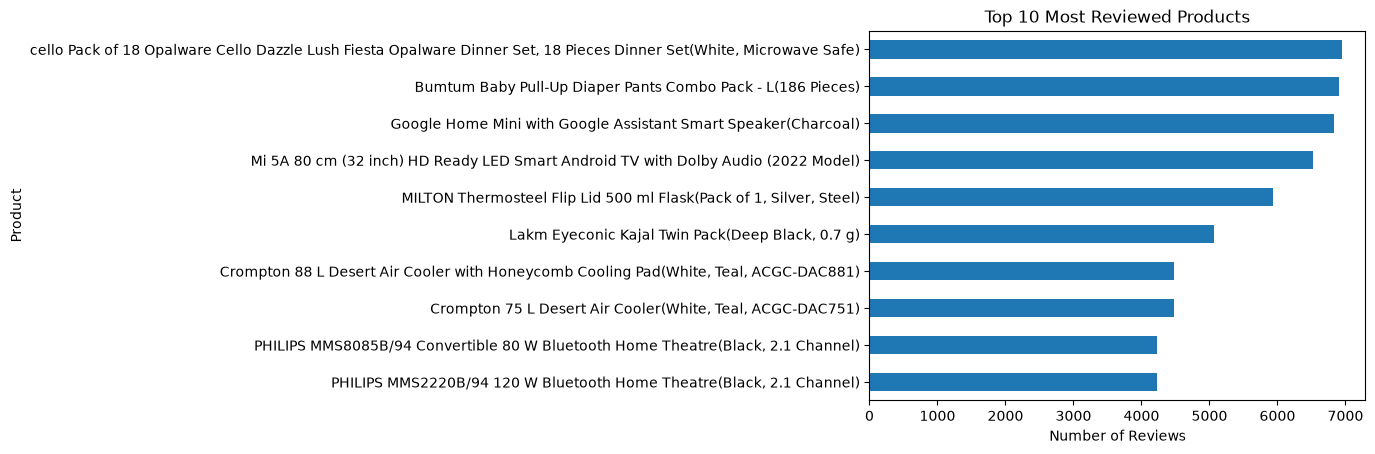

In [46]:
top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Most Reviewed Products")
plt.xlabel("Number of Reviews")
plt.ylabel("Product")

plt.show()

In [48]:
df["Product_name"].nunique()

1152

In [49]:
df.groupby("Product_name")

In [51]:
product_avg_rating = df.groupby("Product_name")["Rate"].mean()

product_avg_rating.head()

Product_name
3D METRO SUPER STORE JUICER_Gduumy 1 Juicer,1 Handle,1 Jar,1 Glass 0 Juicer (1 Jar, Green)                                                                                                                                                                                                                           3.656566
3D METRO SUPER STORE METRO_MIXER Pro 0 Juicer (1 Jar, Multicolor)                                                                                                                                                                                                                                                    4.740741
7SEVEN Airtel DTH Remote Airtel Xstream Remote Compatible with SD and HD Recording Compatible for original Set top or Setup Box Digital tv Remote Control AIRTEL Set Top Box, AIRTEL Xstream - Android TV Set Top Box Remote Controller(Black)                                                                       4.687500
7SEVEN Compatible Infrared Remote

In [52]:
product_stats = df.groupby("Product_name").agg(
    average_rating=("Rate", "mean"),
    total_reviews=("Rate", "count")
).reset_index()

product_stats.head()

,Product_name,average_rating,total_reviews
0,"3D METRO SUPER STORE JUICER_Gduumy 1 Juicer,1 ...",3.656566,99
1,3D METRO SUPER STORE METRO_MIXER Pro 0 Juicer ...,4.740741,27
2,7SEVEN Airtel DTH Remote Airtel Xstream Remote...,4.687500,16
3,7SEVEN Compatible Infrared Remote Control for ...,3.909091,11
4,7SEVEN TCL Remote Control for Smart TV RC802V ...,3.717391,92


In [53]:
product_stats["average_rating"] = (
    product_stats["average_rating"].round(2)
)

In [54]:
product_stats.sort_values(
    by="total_reviews",
    ascending=False
).head(10)

,Product_name,average_rating,total_reviews
1086,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,4.30,6947
119,Bumtum Baby Pull-Up Diaper Pants Combo Pack - ...,3.42,6900
339,Google Home Mini with Google Assistant Smart S...,4.11,6836
577,Mi 5A 80 cm (32 inch) HD Ready LED Smart Andro...,4.25,6522
535,MILTON Thermosteel Flip Lid 500 ml Flask(Pack ...,4.35,5935
510,"Lakm Eyeconic Kajal Twin Pack(Deep Black, 0.7 g)",4.52,5071
183,"Crompton 75 L Desert Air Cooler(White, Teal, A...",4.00,4481
184,Crompton 88 L Desert Air Cooler with Honeycomb...,4.00,4481
655,PHILIPS MMS8085B/94 Convertible 80 W Bluetooth...,4.22,4232
652,PHILIPS MMS2220B/94 120 W Bluetooth Home Theat...,4.23,4224


In [55]:
reliable_products = product_stats[
    product_stats["total_reviews"] >= 100
]

reliable_products.shape

(524, 3)

In [56]:
worst_products = reliable_products.sort_values(
    by="average_rating",
    ascending=True
).head(10)

worst_products

,Product_name,average_rating,total_reviews
412,I Kall N7 2 GB RAM 16 GB ROM 7 inch with Wi-Fi...,1.39,328
519,Lenovo Tab M10 (HD) 4 GB RAM 64 GB ROM 10.1 in...,1.97,275
794,SAMSUNG Galaxy Tab S6 Lite With Stylus 4 GB RA...,2.00,101
797,SAMSUNG Galaxy Tab S6 Lite With Stylus 4 GB RA...,2.00,101
795,SAMSUNG Galaxy Tab S6 Lite With Stylus 4 GB RA...,2.00,101
1124,realme Pad 4 GB RAM 64 GB ROM 10.4 inch with W...,2.05,628
1121,realme Pad 3 GB RAM 32 GB ROM 10.4 inch with W...,2.05,629
1122,realme Pad 3 GB RAM 32 GB ROM 10.4 inch with W...,2.05,627
1123,realme Pad 3 GB RAM 32 GB ROM 10.4 inch with W...,2.06,618
1125,realme Pad 4 GB RAM 64 GB ROM 10.4 inch with W...,2.06,624


In [57]:
best_products = reliable_products.sort_values(
    by="average_rating",
    ascending=False
).head(10)

best_products

,Product_name,average_rating,total_reviews
1025,WDIZE Magic Book For Kids ( 4 Book + 10 Refill...,4.85,115
1112,mCaffeine Coffee Moment Festive Skincare Gift ...,4.82,172
19,APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/M...,4.78,747
208,DOMS Pencil Smart Kit,4.71,1681
1038,WolTop Wall Stickers Wallpaper Happy Winter Tr...,4.66,100
220,Decal O Decal Lord Ganesha with Lotus Wall Sti...,4.65,317
354,HAIR & CARE Triple Blend Damage Repair Non-Sti...,4.65,1478
388,Hamlay by SIGRI-WALA Pack of 40 Melamin Pink D...,4.62,192
259,F&D A180X 84 W Portable Bluetooth Home Theatre...,4.61,200
232,Dinine Craft Set of 4 Showpiece for Home Decor...,4.61,199


In [58]:
negative_df = df[df["sentiment"] == "Negative"]

negative_df.head()


,Product_name,Price,Rate,Review,Summary,full_review,sentiment
12,"Crompton 75 L Desert Air Cooler(White, Teal, A...","??10,499",1.0,Don't waste your money,"Water pump is not throwing a lot of water, tha...",Don't waste your money Water pump is not throw...,Negative
19,"Crompton 75 L Desert Air Cooler(White, Teal, A...","??10,499",1.0,Unsatisfactory,Its vertical Swing quality is bad. When you se...,Unsatisfactory Its vertical Swing quality is b...,Negative
20,"Crompton 75 L Desert Air Cooler(White, Teal, A...","??10,499",1.0,Utterly Disappointed,Never purchase cooler from FlipkartMy 10500 wa...,Utterly Disappointed Never purchase cooler fro...,Negative
60,"Crompton 75 L Desert Air Cooler(White, Teal, A...","??10,499",1.0,Unsatisfactory,Air throw is very disappointing.I thought it w...,Unsatisfactory Air throw is very disappointing...,Negative
65,"Crompton 75 L Desert Air Cooler(White, Teal, A...","??10,499",1.0,Did not meet expectations,It is old model and don't have outlet for drai...,Did not meet expectations It is old model and ...,Negative


In [59]:
negative_counts = (
    negative_df
    .groupby("Product_name")
    .size()
    .reset_index(name="negative_reviews")
)

negative_counts.head()

,Product_name,negative_reviews
0,"3D METRO SUPER STORE JUICER_Gduumy 1 Juicer,1 ...",25
1,3D METRO SUPER STORE METRO_MIXER Pro 0 Juicer ...,1
2,7SEVEN Compatible Infrared Remote Control for ...,1
3,7SEVEN TCL Remote Control for Smart TV RC802V ...,19
4,@Home by nilkamal Walton Engineered Wood TV En...,3


In [60]:
product_stats = product_stats.merge(
    negative_counts,
    on="Product_name",
    how="left"
)

In [61]:
product_stats["negative_reviews"] = (
    product_stats["negative_reviews"].fillna(0)
)

In [62]:
product_stats["negative_percentage"] = (
    product_stats["negative_reviews"]
    / product_stats["total_reviews"]
    * 100
)

In [63]:
product_stats["negative_percentage"] = (
    product_stats["negative_percentage"].round(2)
)

In [64]:
product_stats.head()

,Product_name,average_rating,total_reviews,negative_reviews,negative_percentage
0,"3D METRO SUPER STORE JUICER_Gduumy 1 Juicer,1 ...",3.66,99,25.0,25.25
1,3D METRO SUPER STORE METRO_MIXER Pro 0 Juicer ...,4.74,27,1.0,3.70
2,7SEVEN Airtel DTH Remote Airtel Xstream Remote...,4.69,16,0.0,0.00
3,7SEVEN Compatible Infrared Remote Control for ...,3.91,11,1.0,9.09
4,7SEVEN TCL Remote Control for Smart TV RC802V ...,3.72,92,19.0,20.65


In [65]:
high_risk_products = product_stats[
    (product_stats["total_reviews"] >= 100) &
    (product_stats["negative_percentage"] >= 25)
]

In [66]:
high_risk_products = high_risk_products.sort_values(
    by="negative_percentage",
    ascending=False
)

In [67]:
len(high_risk_products)

105

In [68]:
df["review_length"] = df["full_review"].str.len()

In [69]:
df["word_count"] = df["full_review"].str.split().str.len()

In [70]:
df["word_count"].describe()

count    306316.000000
mean         10.983710
std          13.957349
min           2.000000
25%           4.000000
50%           6.000000
75%          11.000000
max         116.000000
Name: word_count, dtype: float64

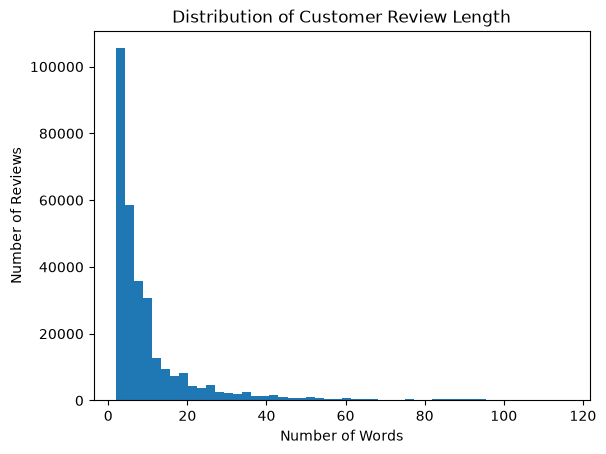

In [71]:
df["word_count"].plot(
    kind="hist",
    bins=50
)

plt.title("Distribution of Customer Review Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.show()

In [72]:
df.to_csv(
    "../data/processed/cleaned_reviews.csv",
    index=False
)

In [73]:
import os

os.path.exists("../data/processed/cleaned_reviews.csv")

True